### This is the notebook for analyzing UCEC data

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from scipy.sparse import csr_matrix

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

import gseapy as gp
from gseapy import barplot, dotplot
from gseapy import Msigdb

import mygene
mg = mygene.MyGeneInfo()

import sys
sys.path.append("..")

from scripts.utility_functions import t_test, clean_data, read_data


omic_type = "proteomics"
omic_type = "RNAseq"


##### Step 1: combine all cancer type into one adata object

In [13]:
### Test
### Skip
cancer_type = "CCRCC"
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"
adata_CCRCC = ad.read_h5ad(object_file)

cancer_type = "PDAC"
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"
adata_COAD = ad.read_h5ad(object_file)
adata_COAD.obs["Cancer_type"] = cancer_type

cancer_type = "HNSCC"
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"
adata_HNSCC = ad.read_h5ad(object_file)
adata_HNSCC.obs["Cancer_type"] = cancer_type

common_genes = list(set.intersection(set(adata_CCRCC.var_names), set(adata_COAD.var_names), set(adata_HNSCC.var_names)))

adata_CCRCC = adata_CCRCC[:, common_genes].copy()
adata_COAD = adata_COAD[:, common_genes].copy()
adata_HNSCC = adata_HNSCC[:, common_genes].copy()

merged_adata = ad.concat([adata_CCRCC, adata_COAD, adata_HNSCC] ,join="inner", merge="same")

### Double check the normalization method
upper_quantile_per_row = np.percentile(adata_HNSCC.X, 75, axis=1)
np.exp2(upper_quantile_per_row)

array([1343.42493829, 1355.11540033, 1352.7691977 , 1362.17845157,
       1343.42493829, 1362.17845157, 1352.7691977 , 1352.7691977 ,
       1327.22752865, 1371.65315197, 1362.17845157, 1324.92961018,
       1324.92961018, 1352.7691977 , 1359.8200202 , 1315.77765285,
       1343.42493829, 1334.1452244 , 1371.65315197, 1324.92961018,
       1336.45912617, 1343.42493829, 1343.42493829, 1288.69934031,
       1324.92961018, 1334.1452244 , 1371.65315197, 1343.42493829,
       1343.42493829, 1352.7691977 , 1336.45912617, 1315.77765285,
       1371.65315197, 1362.17845157, 1362.17845157, 1334.1452244 ,
       1362.17845157, 1343.42493829, 1348.08897182, 1348.08897182,
       1324.92961018, 1334.1452244 , 1306.68891271, 1352.7691977 ,
       1324.92961018, 1297.66295308, 1288.69934031, 1343.42493829,
       1315.77765285, 1362.17845157, 1362.17845157, 1352.7691977 ,
       1315.77765285, 1324.92961018, 1352.7691977 , 1362.17845157,
       1343.42493829, 1362.17845157, 1371.65315197, 1371.65315

<Axes: ylabel='Density'>

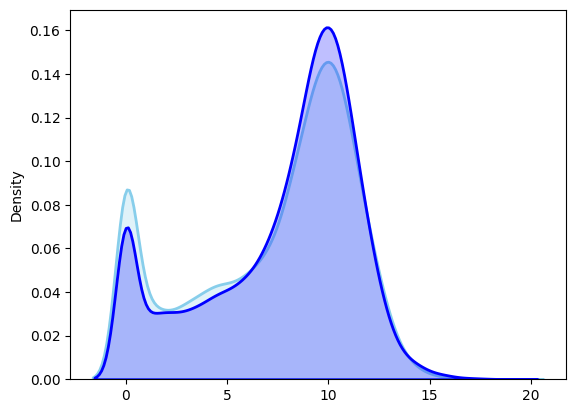

In [15]:
sns.kdeplot(
    data=adata_CCRCC.X[1,],
    fill=True,         # Fills the area under the curve
    color="skyblue",   # Sets the color of the plot
    linewidth=2,       # Thickness of the line
    label="Abundance Density"
)

sns.kdeplot(
    data=adata_COAD.X[1,],
    fill=True,         # Fills the area under the curve
    color="blue",   # Sets the color of the plot
    linewidth=2,       # Thickness of the line
    label="Abundance Density"
)

In [16]:
# define cancer types
cancer_types = ["CCRCC", "HNSCC", "LSCC", "LUAD", "PDAC"]  # fill in your list

base_path = "../../MultiOmics_cancer_landscape_data"
adata_dict = {}

for ct in cancer_types:
    object_file = f"{base_path}/{ct}/Object/{ct}_{omic_type}.h5ad"
    
    print(f"Loading: {object_file}")
    adata = ad.read_h5ad(object_file)

    # Add cancer type column
    adata.obs["CancerType"] = ct

    # Store
    adata_dict[ct] = adata

print("\nLoaded datasets:", list(adata_dict.keys()))

gene_sets = [set(a.var_names) for a in adata_dict.values()]
common_genes = list(set.intersection(*gene_sets))

common_genes.sort()

print(f"The number of common genes found: {len(common_genes)}")
print(f"Frist common 10 genes found: {common_genes[:10]}")

# Update each cancer type only selecting common genes
for ct in adata_dict:
    adata_dict[ct] = adata_dict[ct][:, common_genes].copy()

merged_adata = ad.concat(
    adata_dict.values(),
    join="inner",
    merge="same"   
)

print(f"Merged shape: {merged_adata.shape}")  # (cells, genes)



Loading: ../../MultiOmics_cancer_landscape_data/CCRCC/Object/CCRCC_RNAseq.h5ad
Loading: ../../MultiOmics_cancer_landscape_data/HNSCC/Object/HNSCC_RNAseq.h5ad
Loading: ../../MultiOmics_cancer_landscape_data/LSCC/Object/LSCC_RNAseq.h5ad
Loading: ../../MultiOmics_cancer_landscape_data/LUAD/Object/LUAD_RNAseq.h5ad
Loading: ../../MultiOmics_cancer_landscape_data/PDAC/Object/PDAC_RNAseq.h5ad

Loaded datasets: ['CCRCC', 'HNSCC', 'LSCC', 'LUAD', 'PDAC']
The number of common genes found: 20052
Frist common 10 genes found: ['ENSG00000000003.15', 'ENSG00000000005.6', 'ENSG00000000419.12', 'ENSG00000000457.14', 'ENSG00000000460.17', 'ENSG00000000938.13', 'ENSG00000000971.16', 'ENSG00000001036.14', 'ENSG00000001084.13', 'ENSG00000001167.14']
Merged shape: (862, 20052)


In [17]:
adata.var_names

Index(['ENSG00000000003.15', 'ENSG00000000005.6', 'ENSG00000000419.12',
       'ENSG00000000457.14', 'ENSG00000000460.17', 'ENSG00000000938.13',
       'ENSG00000000971.16', 'ENSG00000001036.14', 'ENSG00000001084.13',
       'ENSG00000001167.14',
       ...
       'ENSG00000287856.1', 'ENSG00000288000.1', 'ENSG00000288053.1',
       'ENSG00000288460.1', 'ENSG00000288520.1', 'ENSG00000288529.1',
       'ENSG00000288558.1', 'ENSG00000288570.1', 'ENSG00000288593.1',
       'ENSG00000288602.1'],
      dtype='object', name='idx', length=20052)

In [20]:
merged_adata.obs

,SampleType,Sample,CancerType
C3L-00004_N,N,C3L-00004,CCRCC
C3L-00010_N,N,C3L-00010,CCRCC
C3L-00011_N,N,C3L-00011,CCRCC
C3L-00026_N,N,C3L-00026,CCRCC
C3L-00079_N,N,C3L-00079,CCRCC
...,...,...,...
C3N-03884_T,T,C3N-03884,PDAC
C3N-04119_T,T,C3N-04119,PDAC
C3N-04126_T,T,C3N-04126,PDAC
C3N-04282_T,T,C3N-04282,PDAC


In [21]:
merged_adata.var

,ensembl_ids_clean,Gene,Gene_proteinatlas,Ensembl,Protein class,Gene description
idx,,,,,,
ENSG00000000003.15,ENSG00000000003,TSPAN6,TSPAN6,ENSG00000000003,Predicted membrane proteins,Tetraspanin 6
ENSG00000000005.6,ENSG00000000005,TNMD,TNMD,ENSG00000000005,Predicted membrane proteins,Tenomodulin
ENSG00000000419.12,ENSG00000000419,DPM1,DPM1,ENSG00000000419,"Disease related genes, Enzymes, Human disease ...",Dolichyl-phosphate mannosyltransferase subunit...
ENSG00000000457.14,ENSG00000000457,SCYL3,SCYL3,ENSG00000000457,"Enzymes, Predicted intracellular proteins",SCY1 like pseudokinase 3
ENSG00000000460.17,ENSG00000000460,FIRRM,C1orf112,ENSG00000000460,Predicted intracellular proteins,Chromosome 1 open reading frame 112
...,...,...,...,...,...,...
ENSG00000288529.1,ENSG00000288529,LOC128092253,ENSG00000288529,ENSG00000288529,Predicted intracellular proteins,Novel protein
ENSG00000288558.1,ENSG00000288558,DUS4L-BCAP29,DUS4L-BCAP29,ENSG00000288558,Predicted membrane proteins,DUS4L-BCAP29 readthrough
ENSG00000288570.1,ENSG00000288570,LOC128092248,ENSG00000288570,ENSG00000288570,Predicted intracellular proteins,Novel protein


# Add the protein atlas gene description

In [ ]:
if omic_type == "proteomics":
    gene_function = pd.read_csv("../../MultiOmics_cancer_landscape_data/proteinatlas.tsv", sep="\t")
    gene_function = gene_function.loc[:, ["Gene", "Ensembl", "Protein class", "Gene description"]]
    gene_function

    # Merge into AnnData
    merged_adata.var = merged_adata.var.merge(
        gene_function,
        on="Gene",      # merge using the gene name column
        how="left"
    )

,Gene,Ensembl,Protein class,Gene description
0,TSPAN6,ENSG00000000003,Predicted membrane proteins,Tetraspanin 6
1,TNMD,ENSG00000000005,Predicted membrane proteins,Tenomodulin
2,DPM1,ENSG00000000419,"Disease related genes, Enzymes, Human disease ...",Dolichyl-phosphate mannosyltransferase subunit...
3,SCYL3,ENSG00000000457,"Enzymes, Predicted intracellular proteins",SCY1 like pseudokinase 3
4,C1orf112,ENSG00000000460,Predicted intracellular proteins,Chromosome 1 open reading frame 112
...,...,...,...,...
20157,ENSG00000291313,ENSG00000291313,Predicted intracellular proteins,Novel protein
20158,ENSG00000291314,ENSG00000291314,Predicted intracellular proteins,Novel protein
20159,ENSG00000291315,ENSG00000291315,Predicted intracellular proteins,Novel protein
20160,ENSG00000291316,ENSG00000291316,Predicted intracellular proteins,"Novel protein, LOC84773-CYHR1 readthrough"


In [22]:
object_file = f"../../MultiOmics_cancer_landscape_data/combined_cancer_types_RNAseq.h5ad"

merged_adata.write(object_file, compression="gzip")

##### Step 2: ML

In [23]:
### Main ML workflow 

# Load data
object_file = f"../../MultiOmics_cancer_landscape_data/combined_cancer_types_RNAseq.h5ad"
adata = ad.read_h5ad(object_file)

X = adata.X
y_ori = adata.obs["SampleType"].values
#samples = adata.obs["Sample"].values  # sample names or IDs
sample_types = adata.obs["SampleType"].values
cancer_types = adata.obs["CancerType"].values
samples = adata.obs.index

# Encode labels
# LabelEncoder assigns integers alphabetically by default, so if your labels are "N" and "T" you’ll usually get "Normal" = 0, "Tumor" = 1
encoder = LabelEncoder()
y = encoder.fit_transform(y_ori)

# Ensure "Normal" = 0, "Tumor" = 1
if encoder.transform(["T"])[0] == 0:
    y = 1 - y  # flip labels

# Split train/test and also get the indices of the test set
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, range(len(y)), test_size=0.3, random_state=42, stratify=y, shuffle=True
)

adata_train = adata[samples[idx_train], ]
adata_test = adata[samples[idx_test], ]

# Train Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

adata_train = t_test(adata_obj = adata_train, sample_type_col= "SampleType", left_type = "T", right_type="N")

adata_train.var["feature_importance"] = rf.feature_importances_


In [24]:
rf

RandomForestClassifier(n_estimators=500, random_state=42)

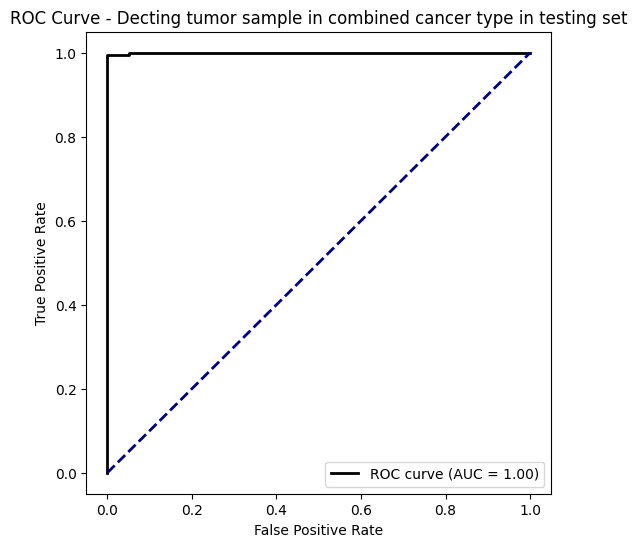

In [25]:
cancer_type = "combined cancer type"

### Prediction
y_proba = rf.predict_proba(X_test)[:, 1]  # Probability of class 1 (Tumor)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color = "black", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color = "navy", lw=2, linestyle= "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Decting tumor sample in {cancer_type} in testing set")
plt.legend(loc="lower right")

# Save to PDF
pdf_file = f"../results/figures/{cancer_type}_{omic_type}_ROC_in_testing_set.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

plt.show()


In [26]:
cancer_type

'combined cancer type'

     idx_test       Sample Sample_Type cancer_Type  y_test  y_pred
0         225  C3L-00997_T           T       HNSCC       1   0.996
1         264  C3N-01758_T           T       HNSCC       1   0.986
2         715  C3N-01799_T           T        LUAD       1   0.954
3         306  C3N-03664_T           T       HNSCC       1   0.966
4         235  C3L-04791_T           T       HNSCC       1   0.968
..        ...          ...         ...         ...     ...     ...
254        72  C3L-00004_T           T       CCRCC       1   0.968
255       134  C3N-00194_T           T       CCRCC       1   0.940
256       191  C3N-01338_N           N       HNSCC       0   0.068
257       530  C3N-04162_T           T        LSCC       1   0.956
258       429  C3L-00923_T           T        LSCC       1   0.926

[259 rows x 6 columns]


/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/3728186262.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=performance, x="Sample_Type", y="y_pred", palette=custom_palette)


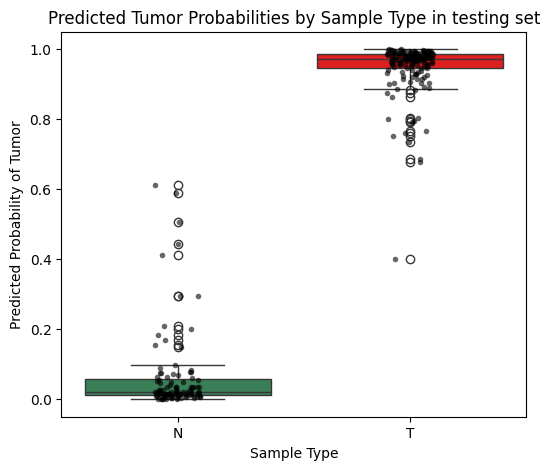

In [27]:

### Create performance DataFrame with Sample info and visualize the proba in testing set
performance = pd.DataFrame({
    "idx_test": idx_test,
    "Sample": samples[idx_test],   # sample names
    "Sample_Type": sample_types[idx_test],
    "cancer_Type": cancer_types[idx_test],
    "y_test": y_test,
    "y_pred": y_proba
})

print(performance)

performance_sort = performance.sort_values("y_pred").reset_index(drop=True)

#pd.set_option("display.max_rows", None)
#print(performance_sort)

### Boxplot on the prediction score in testing set
custom_palette = {"N": "seagreen", "T": "red"}

plt.figure(figsize=(6,5))
sns.boxplot(data=performance, x="Sample_Type", y="y_pred", palette=custom_palette)
sns.stripplot(data=performance, x="Sample_Type", y="y_pred", color="black", size=4, jitter=True, alpha=0.6)
plt.ylabel("Predicted Probability of Tumor")
plt.xlabel("Sample Type")
plt.title("Predicted Tumor Probabilities by Sample Type in testing set")

# Save to PDF
#pdf_file = f"../results/figures/{cancer_type}_{omic_type}_Proba_in_testing_set.pdf"
#plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

plt.show()

In [29]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
feature_importance_sort.head(10)

,ensembl_ids_clean,Gene,Gene_proteinatlas,Ensembl,Protein class,Gene description,left_mean,right_mean,diff_mean,t_vals,p_vals,feature_importance
idx,,,,,,,,,,,,
ENSG00000141338.14,ENSG00000141338,ABCA8,ABCA8,ENSG00000141338,"Metabolic proteins, Predicted membrane protein...",ATP binding cassette subfamily A member 8,8.464864973262033,11.803615720524018,-3.338751,-34.918935,1.291638e-142,0.010557
ENSG00000140092.14,ENSG00000140092,FBLN5,FBLN5,ENSG00000140092,"Disease related genes, Human disease related g...",Fibulin 5,9.379310427807487,11.540651965065502,-2.161342,-28.685325,4.510863e-114,0.009459
ENSG00000069702.11,ENSG00000069702,TGFBR3,TGFBR3,ENSG00000069702,"Cancer-related genes, Plasma proteins, Predict...",Transforming growth factor beta receptor 3,9.864572727272726,11.953820087336242,-2.089247,-33.729265,1.968594e-137,0.009185
ENSG00000099953.10,ENSG00000099953,MMP11,MMP11,ENSG00000099953,"Cancer-related genes, Enzymes, Predicted secre...",Matrix metallopeptidase 11,10.974605882352941,5.914668122270742,5.059938,32.410725,2.999147e-131,0.008676
ENSG00000164932.13,ENSG00000164932,CTHRC1,CTHRC1,ENSG00000164932,"Disease related genes, Human disease related g...",Collagen triple helix repeat containing 1,10.53148449197861,6.858968995633187,3.672515,30.774756,7.602593e-119,0.008142
ENSG00000169258.7,ENSG00000169258,GPRIN1,GPRIN1,ENSG00000169258,Predicted intracellular proteins,G protein regulated inducer of neurite outgrow...,7.662026203208556,5.366882969432314,2.295143,31.558393,6.287799e-128,0.007910
ENSG00000168309.18,ENSG00000168309,FAM107A,FAM107A,ENSG00000168309,Predicted intracellular proteins,Family with sequence similarity 107 member A,7.147428877005347,10.919433187772926,-3.772004,-33.141864,3.152213e-134,0.007715
ENSG00000122565.19,ENSG00000122565,CBX3,CBX3,ENSG00000122565,"Plasma proteins, Predicted intracellular proteins",Chromobox 3,11.97461550802139,11.067478165938864,0.907137,33.584993,9.021736e-140,0.007444
ENSG00000184905.9,ENSG00000184905,TCEAL2,TCEAL2,ENSG00000184905,Predicted intracellular proteins,Transcription elongation factor A like 2,3.2842614973262036,6.667153711790394,-3.382892,-30.256382,2.969520e-120,0.007356


In [30]:

#feature_importance_sort.to_csv("../../MultiOmics_cancer_landscape_data/feature_importance_sort.csv", index=False)

feature_importance_sort.to_excel("../../MultiOmics_cancer_landscape_data/feature_importance_sort_RNAseq.xlsx", index=False)


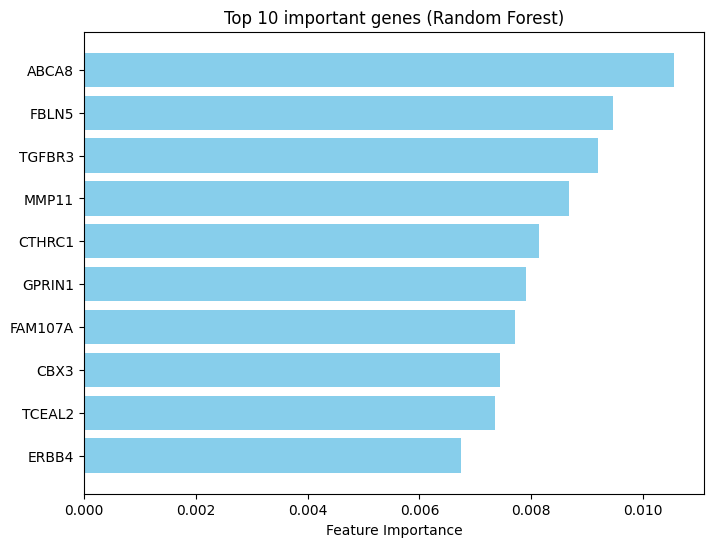

In [31]:
top_n = 10
plt.figure(figsize=(8,6))
plt.barh(
    feature_importance_sort['Gene'][:top_n][::-1],
    feature_importance_sort['feature_importance'][:top_n][::-1],
    color='skyblue'
)
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} important genes (Random Forest)")
plt.show()


#### Step 3: Explore the features with biological input

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/1348488528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


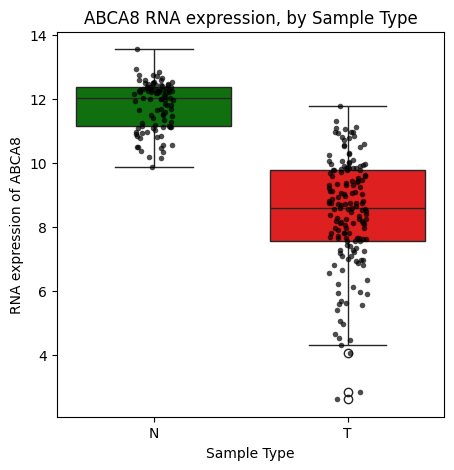

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/1348488528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


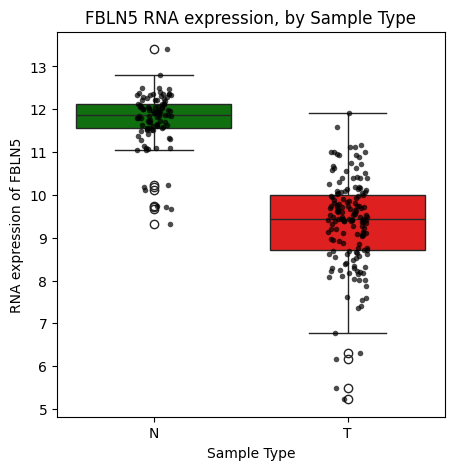

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/1348488528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


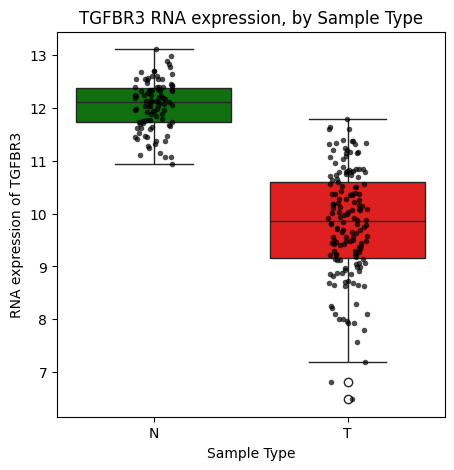

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/1348488528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


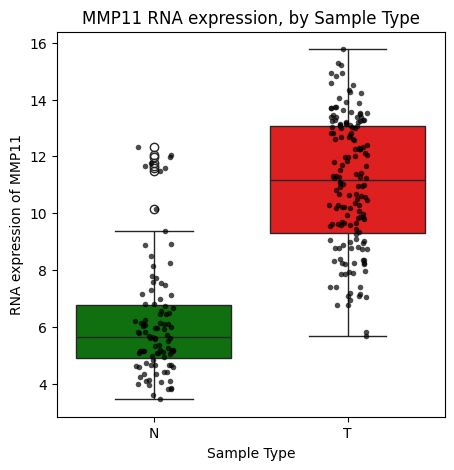

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/1348488528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


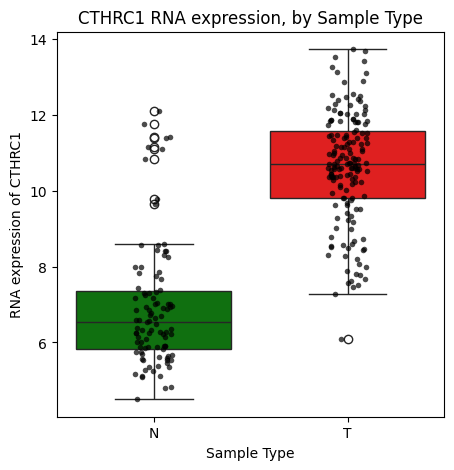

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/1348488528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


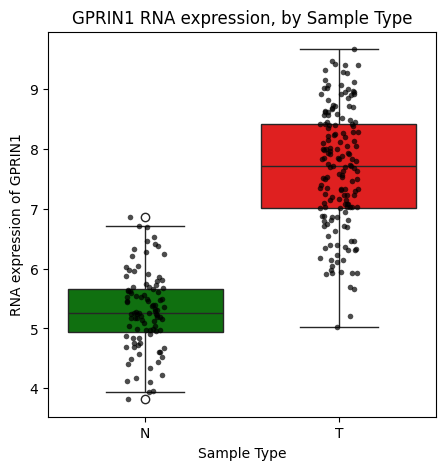

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/1348488528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


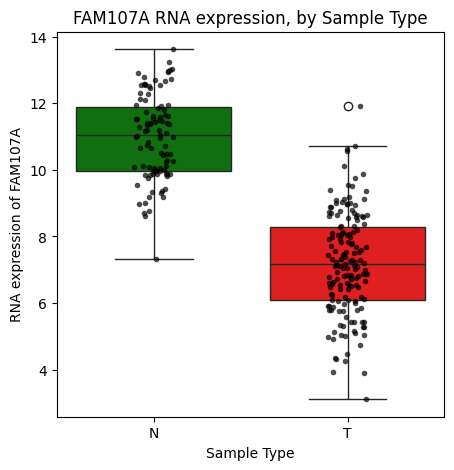

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/1348488528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


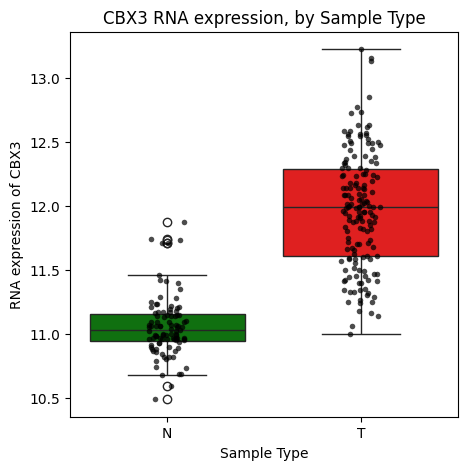

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/1348488528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


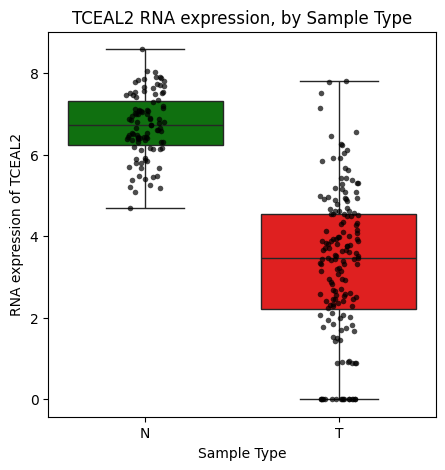

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/1348488528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


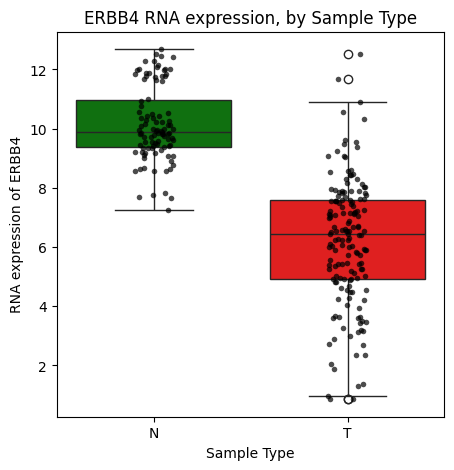

In [34]:
### Boxplot on important genes in testing set
selected_genes = feature_importance_sort.iloc[0:10, ].index.to_list()

df = pd.DataFrame(
    adata_test.X, 
    index=adata_test.obs.index,
    columns=adata_test.var.index  # or adata.var['Gene'] if you prefer gene symbols
).join(adata_test.obs)


for gene in selected_genes:
    
    plt.figure(figsize=(5,5))
    sns.boxplot(
        data=df, 
        x="SampleType", 
        y=gene, 
        palette={"N": "green", "T": "red"}
    )
    sns.stripplot(
        data=df, 
        x="SampleType", 
        y=gene, 
        color="black", 
        size=4, 
        jitter=True, 
        alpha=0.7
    )
    plt.ylabel(f"RNA expression of {adata.var.loc[gene, 'Gene']}")
    plt.xlabel("Sample Type")
    plt.title(f"{adata.var.loc[gene, 'Gene']} RNA expression, by Sample Type")
    plt.show()


### SLC16A3 is cell surface protein    



In [35]:

### Heatmap on top 200 important genes on testing set

selected_genes = feature_importance_sort.iloc[0:200, ].index.to_list()
adata_test_selected_genes = adata_test[:, selected_genes]

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(adata_test_selected_genes.X),
    columns=adata_test_selected_genes.var["Gene"],    # genes
    index=adata_test_selected_genes.obs.index   # samples
)
df_scaled_T = df_scaled.T
# Map disease status to colors
samples_type_col = "SampleType"
lut = {"T": "red", "N": "seagreen"}
samples_type_colors = adata_test_selected_genes.obs[samples_type_col].map(lut).to_dict()

# Map Cancer type to colors
cancer_type_col = "CancerType"
unique_cancers = adata_test_selected_genes.obs[cancer_type_col].unique()
import matplotlib
palette = matplotlib.cm.get_cmap("tab10", len(unique_cancers))
lut_cancer = {cancer: matplotlib.colors.rgb2hex(palette(i))
              for i, cancer in enumerate(unique_cancers)}
cancer_type_colors = adata_test_selected_genes.obs[cancer_type_col].map(lut_cancer).to_dict()


col_colors = pd.DataFrame({
    "SampleType": samples_type_colors,
    "CancerType": cancer_type_colors
}, index=adata_test_selected_genes.obs.index)


/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/177053053.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = matplotlib.cm.get_cmap("tab10", len(unique_cancers))


/Users/wzhang/miniforge3/envs/C2S/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/wzhang/miniforge3/envs/C2S/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 900x900 with 0 Axes>

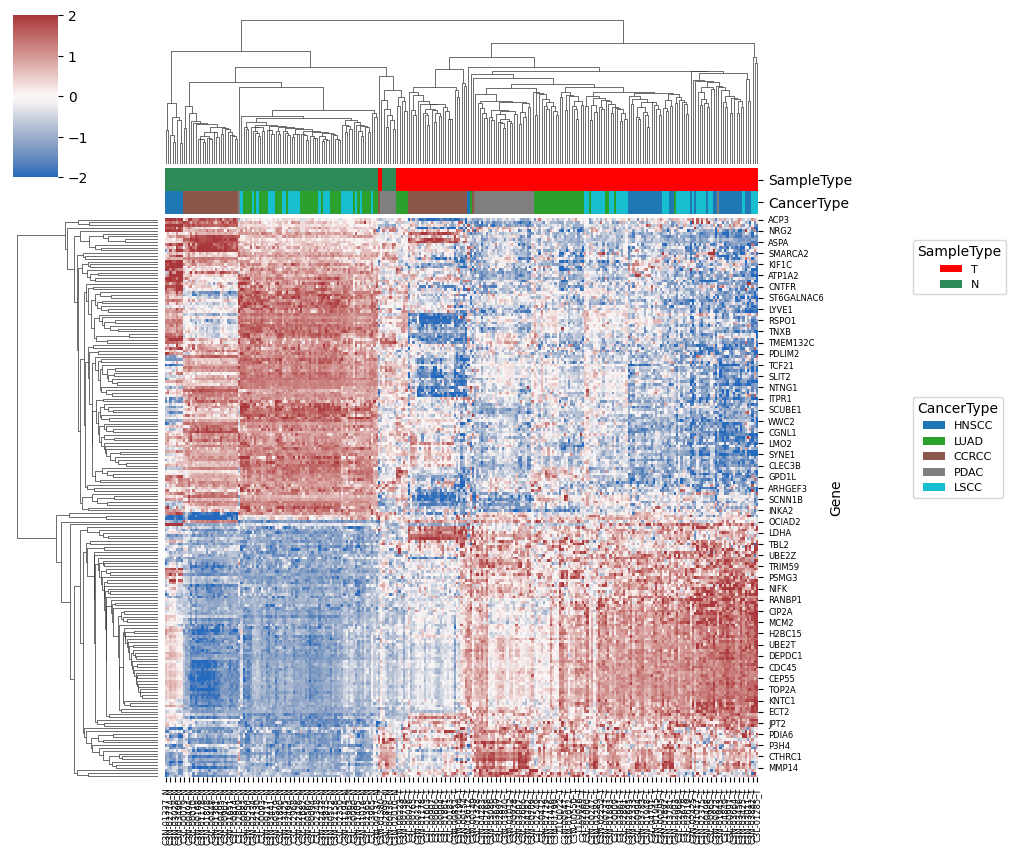

In [37]:
from matplotlib.patches import Patch

# Heatmap (keep your existing sns.clustermap code)
fig = plt.figure(figsize =(9,9))
g = sns.clustermap(
    df_scaled_T,
    col_colors=col_colors,
    cmap="vlag",
    method="average",
    center=0,
    vmin=-2,
    vmax=2,
    xticklabels=True,
    yticklabels=True,
    figsize=(9,9)
)

# Skip labels for readability
yticks = g.ax_heatmap.get_yticks()
ylabels = [lab.get_text() for lab in g.ax_heatmap.get_yticklabels()]
g.ax_heatmap.set_yticks(yticks[::4])
g.ax_heatmap.set_yticklabels(ylabels[::4], fontsize=6, rotation=0)

xticks = g.ax_heatmap.get_xticks()
xlabels = [lab.get_text() for lab in g.ax_heatmap.get_xticklabels()]
g.ax_heatmap.set_xticks(xticks[::2])
g.ax_heatmap.set_xticklabels(xlabels[::2], fontsize=6, rotation=90)

# Create legend handles
handles_samples = [Patch(facecolor=lut[name], label=name) for name in lut]
handles_cancer = [Patch(facecolor=lut_cancer[name], label=name) for name in lut_cancer]

# Attach legends to the figure (not the axes) on the right
g.fig.legend(
    handles=handles_samples,
    title=samples_type_col,
    loc="center left",
    bbox_to_anchor=(1.02, 0.7),  # slightly to the right
    borderaxespad=0.,
    fontsize=8
)

g.fig.legend(
    handles=handles_cancer,
    title=cancer_type_col,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # lower than the first
    borderaxespad=0.,
    fontsize=8
)

plt.show()


In [38]:
print(np.isfinite(df_scaled_T.values).all()) 

True


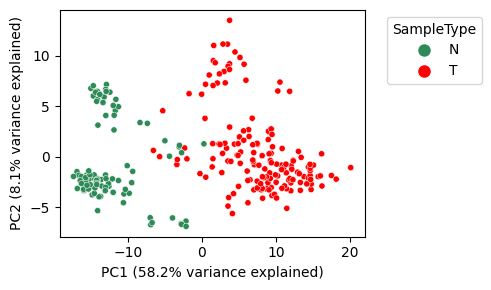

In [39]:

### PCA on top 200 important genes on testing set

scaler = StandardScaler()
df_scaled = scaler.fit_transform(adata_test_selected_genes.X)
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(
    data = pca_result[:, :2],
    columns= ['PC1', 'PC2'],
    index = adata_test_selected_genes.obs.index
).join(adata_test_selected_genes.obs)

var_explained = pca.explained_variance_ratio_ * 100

disease_status_col = "SampleType"
color_dict = {
    'T': 'red',      # Red
    'N': 'seagreen'   # Green
}
legend_order = ['N', 'T']

fig = plt.figure(figsize =(6,3))
sns.scatterplot(
    data = df_pca,
    x = 'PC1',
    y = 'PC2',
    hue = disease_status_col,
    s = 20,
    palette=color_dict
)

plt.xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)')
plt.ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)')

# Create handles and labels in the specific order
handles = []
labels = []
for category in legend_order:
    if category in color_dict:  # Make sure the category exists in your dictionary
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[category], markersize=10))
        labels.append(category)

# Create the legend with the ordered handles and labels
plt.legend(handles, labels, title=disease_status_col, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1])  
plt.show()



/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/4220163937.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = matplotlib.cm.get_cmap("tab10", len(unique_cancers))


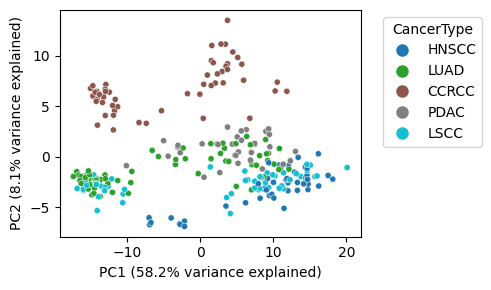

In [40]:

### PCA on top 200 important genes on testing set

scaler = StandardScaler()
df_scaled = scaler.fit_transform(adata_test_selected_genes.X)
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(
    data = pca_result[:, :2],
    columns= ['PC1', 'PC2'],
    index = adata_test_selected_genes.obs.index
).join(adata_test_selected_genes.obs)

var_explained = pca.explained_variance_ratio_ * 100

# Map Cancer type to colors
cancer_type_col = "CancerType"
unique_cancers = adata_test_selected_genes.obs[cancer_type_col].unique()
import matplotlib
palette = matplotlib.cm.get_cmap("tab10", len(unique_cancers))
color_dict_cancer_type = {cancer: matplotlib.colors.rgb2hex(palette(i))
              for i, cancer in enumerate(unique_cancers)}

legend_order = color_dict_cancer_type.keys()

fig = plt.figure(figsize =(6,3))
sns.scatterplot(
    data = df_pca,
    x = 'PC1',
    y = 'PC2',
    hue = cancer_type_col,
    s = 20,
    palette=color_dict_cancer_type
)

plt.xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)')
plt.ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)')

# Create handles and labels in the specific order
handles = []
labels = []
color_dict = color_dict_cancer_type.copy()
for category in legend_order:
    if category in color_dict:  # Make sure the category exists in your dictionary
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[category], markersize=10))
        labels.append(category)

# Create the legend with the ordered handles and labels
plt.legend(handles, labels, title=cancer_type_col, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1])  
plt.show()



/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/1867634640.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] > 0]["Gene"].to_list()


          Gene_set                                     Term Overlap   P-value  \
0  KEGG_2021_Human                               Cell cycle   6/124  0.000026   
1  KEGG_2021_Human                          DNA replication    3/36  0.000642   
2  KEGG_2021_Human                  HIF-1 signaling pathway   4/109  0.001747   
3  KEGG_2021_Human  Human T-cell leukemia virus 1 infection   5/219  0.003750   
4  KEGG_2021_Human      Central carbon metabolism in cancer    3/70  0.004384   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.002282            0                     0   11.433744   
1          0.027906            0                     0   19.853147   
2          0.050658            0                     0    8.381376   
3          0.076274            0                     0    5.169589   
4          0.076274            0                     0    9.761686   

   Combined Score                             Genes  
0      120.610154  CCNA2;CCNB1;CDC45;B

<Axes: title={'center': 'UpRegulated 94 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

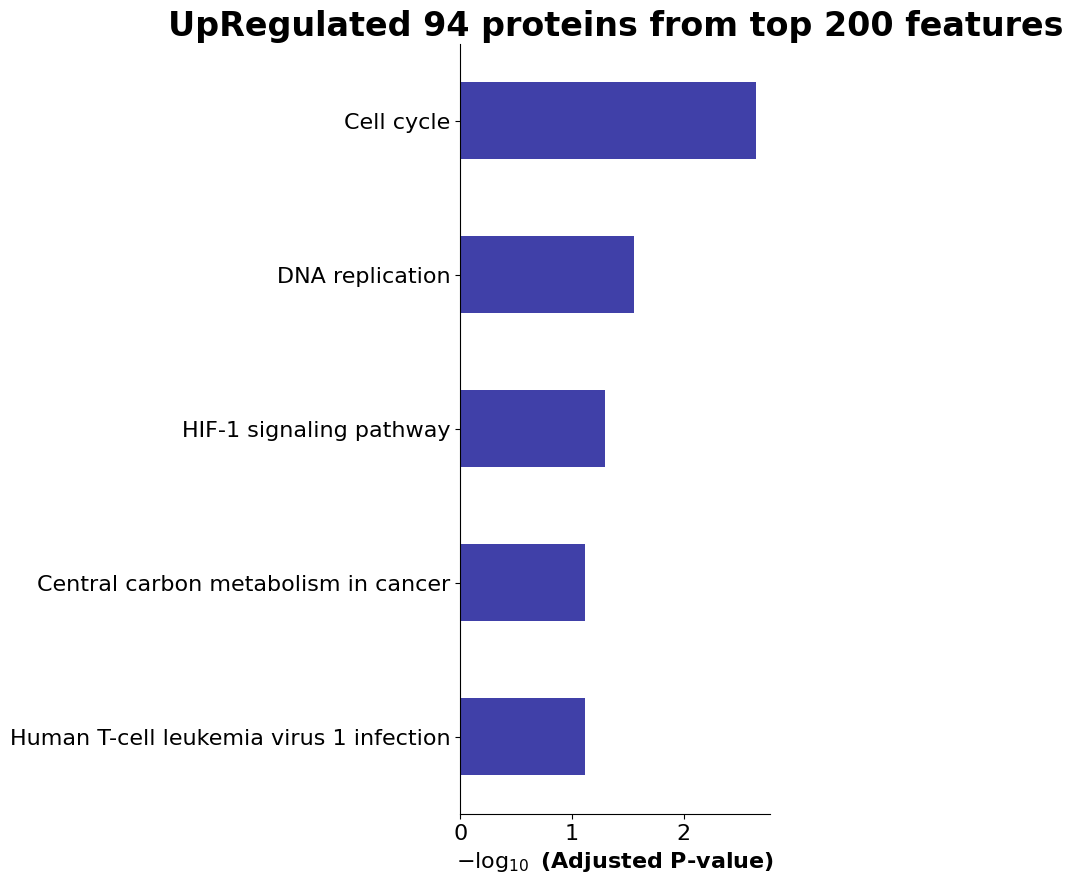

In [41]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] > 0]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 #gene_sets=['MSigDB_Hallmark_2020'],
                 gene_sets=['KEGG_2021_Human'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'UpRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')

In [42]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] < 0]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 #gene_sets=['MSigDB_Hallmark_2020'],
                 gene_sets=['KEGG_2021_Human'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'DownRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')

/var/folders/fw/7fvd0mjd5zn0z9v4wq8_h6ww0000gn/T/ipykernel_71644/3919987112.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] < 0]["Gene"].to_list()


          Gene_set                                       Term Overlap  \
0  KEGG_2021_Human  Aldosterone-regulated sodium reabsorption    3/37   
1  KEGG_2021_Human                       Histidine metabolism    2/22   
2  KEGG_2021_Human    Proximal tubule bicarbonate reclamation    2/23   
3  KEGG_2021_Human                             Tight junction   4/169   
4  KEGG_2021_Human           Fc gamma R-mediated phagocytosis    3/97   

    P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0  0.000986          0.143001            0                     0   17.013135   
1  0.005998          0.291160            0                     0   19.109615   
2  0.006547          0.291160            0                     0   18.198718   
3  0.012546          0.291160            0                     0    4.689008   
4  0.014886          0.291160            0                     0    6.135096   

   Combined Score                    Genes  
0      117.758771     SCNN1G;SCNN1B

ValueError: Warning: No enrich terms when cutoff = 0.1

In [43]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 #gene_sets=['MSigDB_Hallmark_2020'],
                 gene_sets=['KEGG_2021_Human'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'DisRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')

          Gene_set                                       Term Overlap  \
0  KEGG_2021_Human                                 Cell cycle   6/124   
1  KEGG_2021_Human        Central carbon metabolism in cancer    4/70   
2  KEGG_2021_Human                            DNA replication    3/36   
3  KEGG_2021_Human  Aldosterone-regulated sodium reabsorption    3/37   
4  KEGG_2021_Human                        Pyruvate metabolism    3/47   

    P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0  0.001559          0.269710            0                     0    5.158658   
1  0.005320          0.269710            0                     0    6.102041   
2  0.005517          0.269710            0                     0    9.121827   
3  0.005960          0.269710            0                     0    8.853090   
4  0.011565          0.369834            0                     0    6.837563   

   Combined Score                             Genes  
0       33.343118  CCNA2;C

ValueError: Warning: No enrich terms when cutoff = 0.1